In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pyFAI
from integration.frame_loader import DanMaxDataset, PONI_PATH, dark
from diffractom import Material
from matplotlib.patches import Rectangle

dark()


i_trans= 45 (dty= -0.3600)  i_omega=    0 (omega=   0.00)
i_trans= 45 (dty= -0.3600)  i_omega=  750 (omega=  89.97)
i_trans= 45 (dty= -0.3600)  i_omega= 1500 (omega= 179.94)
i_trans= 45 (dty= -0.3600)  i_omega= 2251 (omega= 270.03)
i_trans= 45 (dty= -0.3600)  i_omega= 3001 (omega= 360.00)
i_trans= 90 (dty=  0.0000)  i_omega=    0 (omega=   0.00)
i_trans= 90 (dty=  0.0000)  i_omega=  750 (omega=  89.97)
i_trans= 90 (dty=  0.0000)  i_omega= 1500 (omega= 179.94)
i_trans= 90 (dty=  0.0000)  i_omega= 2251 (omega= 270.03)
i_trans= 90 (dty=  0.0000)  i_omega= 3001 (omega= 360.00)
i_trans=135 (dty=  0.3800)  i_omega=    0 (omega=   0.00)
i_trans=135 (dty=  0.3800)  i_omega=  750 (omega=  89.97)
i_trans=135 (dty=  0.3800)  i_omega= 1500 (omega= 179.94)
i_trans=135 (dty=  0.3800)  i_omega= 2251 (omega= 270.03)
i_trans=135 (dty=  0.3800)  i_omega= 3001 (omega= 360.00)


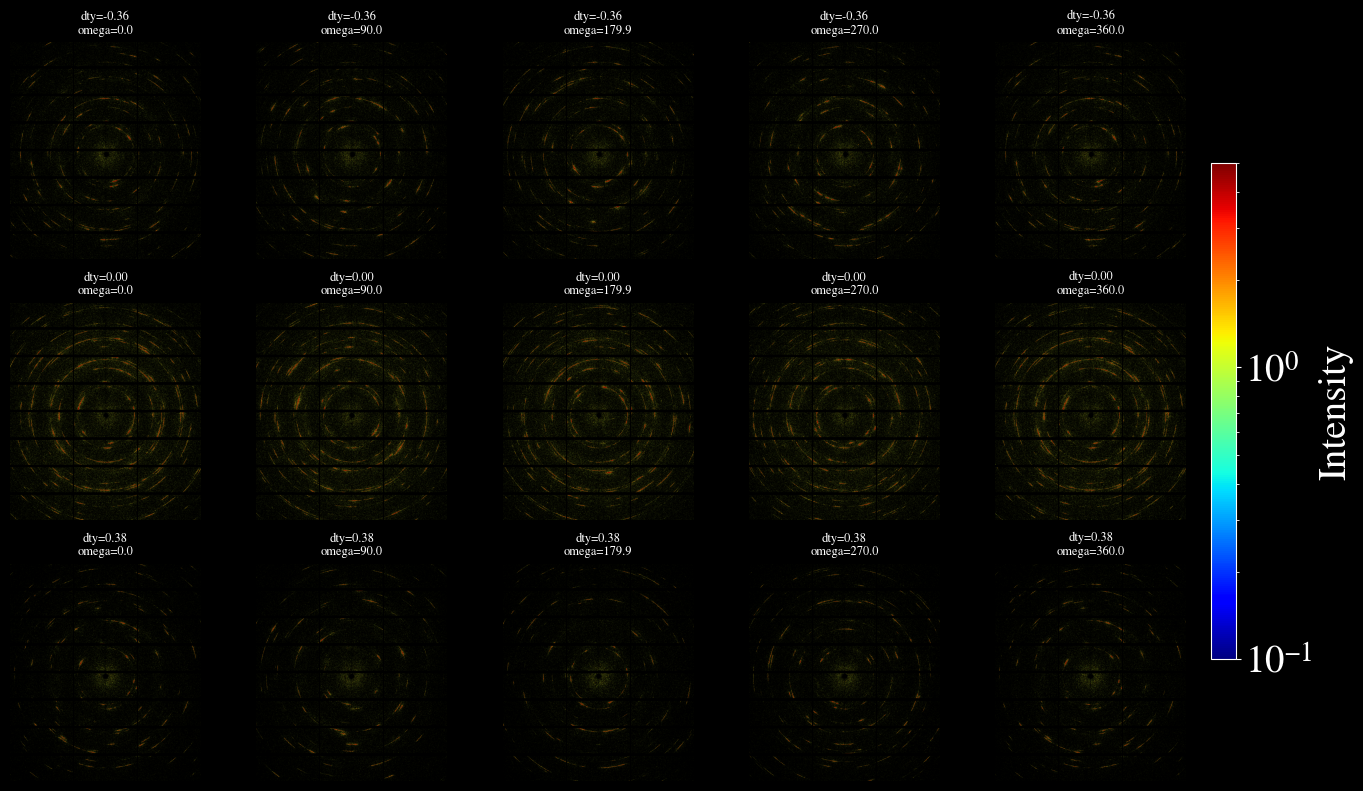

In [2]:
target_trans_frac = [0.25, 0.5, 0.75]
target_omega_deg = [0, 90, 180, 270, 360]  # assumes omega is in degrees -- check the printed values below

with DanMaxDataset() as ds:
    n_trans = ds.n_translations
    i_trans_list = [int(round(f * (n_trans - 1))) for f in target_trans_frac]

    fig, axes = plt.subplots(
        len(i_trans_list), len(target_omega_deg),
        figsize=(3.2 * len(target_omega_deg), 3.2 * len(i_trans_list)),
        squeeze=False,
    )

    im = None
    for row, i_trans in enumerate(i_trans_list):
        omega = ds.omega(i_trans)       # actual motor positions for this block
        dty_val = ds.translations()[i_trans]

        for col, target in enumerate(target_omega_deg):
            i_omega = int(np.argmin(np.abs(omega - target)))
            frame = ds.frame(i_trans, i_omega)

            print(
                f"i_trans={i_trans:3d} (dty={dty_val:8.4f})  "
                f"i_omega={i_omega:5d} (omega={omega[i_omega]:7.2f})"
            )

            ax = axes[row, col]
            im = ax.imshow(frame, vmin=0.1, vmax=5, norm="log", cmap="jet")
            ax.set_title(f"dty={dty_val:.2f}\nomega={omega[i_omega]:.1f}", fontsize=9)
            ax.axis("off")

    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="Intensity")
    plt.show()

In [3]:

# ai = pyFAI.load(PONI_PATH)

# # fine binning -- this is for finding rings, so go finer than the eventual
# # per-ring integration will need
# npt_rad = 2000
# npt_azim = 360

# target_trans_frac = [0.25, 0.5, 0.75]
# target_omega_deg = [0, 90, 180, 270, 360]

# I_sum, q, chi = None, None, None

# with DanMaxDataset() as ds:
#     mask = ds.mask()
#     n_trans = ds.n_translations
#     i_trans_list = [int(round(f * (n_trans - 1))) for f in target_trans_frac]

#     for i_trans in i_trans_list:
#         omega = ds.omega(i_trans)
#         for target in target_omega_deg:
#             i_omega = int(np.argmin(np.abs(omega - target)))
#             frame = ds.frame(i_trans, i_omega)

#             res = ai.integrate2d(
#                 frame,
#                 npt_rad=npt_rad,
#                 npt_azim=npt_azim,
#                 unit="q_nm^-1",
#                 mask=mask,
#                 method=("no", "csr", "opencl"),
#             )

#             if I_sum is None:
#                 I_sum = np.zeros_like(res.intensity)
#                 q, chi = res.radial, res.azimuthal

#             I_sum += res.intensity

# I_sum = np.nan_to_num(I_sum)  # empty/masked bins can come back as nan or 0

# # --- plot, same theme as before ---
# vmin = max(I_sum[I_sum > 0].min(), 1)
# vmax = np.percentile(I_sum, 99.9)

# fig, ax = plt.subplots(1, 1, figsize=(14, 14))
# im = ax.imshow(
#     I_sum,
#     extent=[q.min(), q.max(), chi.min(), chi.max()],
#     origin="lower",
#     aspect="auto",
#     vmin=vmin, vmax=vmax, norm="log",
#     cmap="jet",
# )
# ax.set_xlabel(r"q (nm$^{-1}$)")
# ax.set_ylabel("azimuthal angle (deg)")
# fig.colorbar(im, ax=ax, fraction=0.052, pad=0.04, label="summed intensity")
# for spine in ax.spines.values():
#     spine.set_visible(False)
# plt.tight_layout()
# plt.show()

21 distinct predicted peaks within the detector's q-range


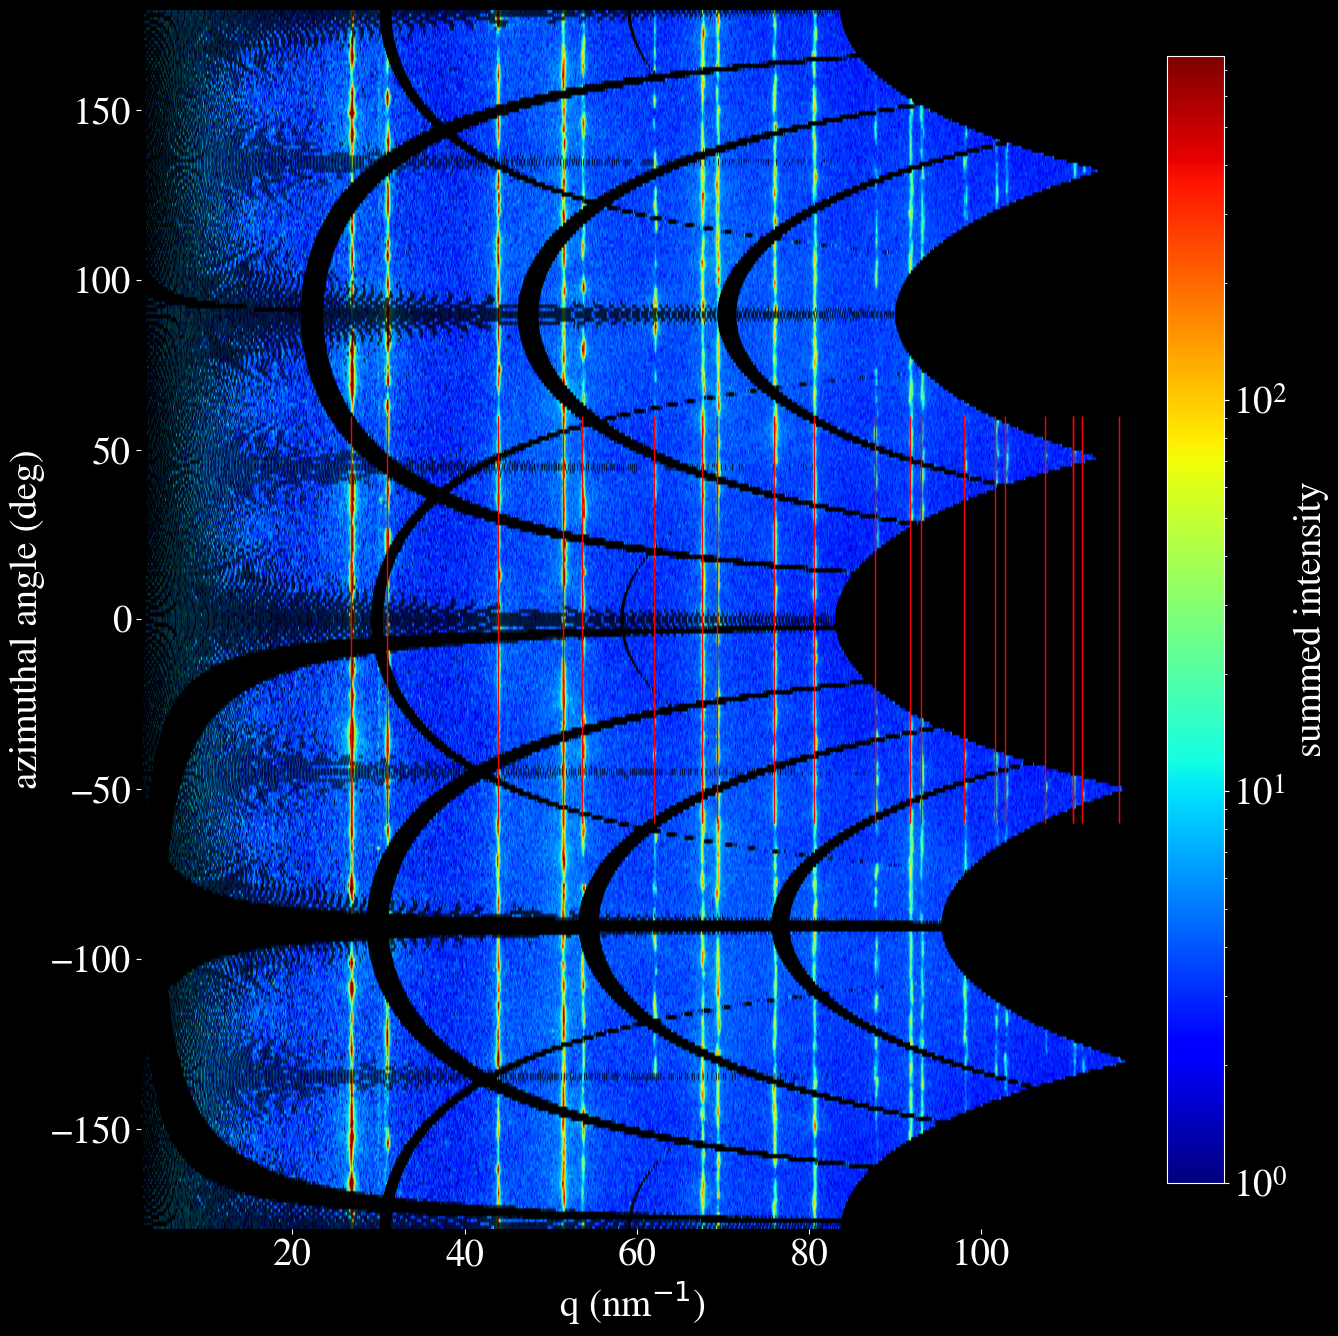

In [4]:
import pyFAI
import numpy as np
import matplotlib.pyplot as plt
from diffractom import Material
from integration.frame_loader import DanMaxDataset, PONI_PATH, PARAMETERS_AL1050

# --- load geometry and integrate as before ---
ai = pyFAI.load(PONI_PATH)

npt_rad = 2000
npt_azim = 360

target_trans_frac = [0.25, 0.5, 0.75]
target_omega_deg = [0, 90, 180, 270, 360]

I_sum, q, chi = None, None, None

with DanMaxDataset() as ds:
    mask = ds.mask()
    n_trans = ds.n_translations
    i_trans_list = [int(round(f * (n_trans - 1))) for f in target_trans_frac]

    for i_trans in i_trans_list:
        omega = ds.omega(i_trans)
        for target in target_omega_deg:
            i_omega = int(np.argmin(np.abs(omega - target)))
            frame = ds.frame(i_trans, i_omega)

            res = ai.integrate2d(
                frame,
                npt_rad=npt_rad,
                npt_azim=npt_azim,
                unit="q_nm^-1",
                mask=mask,
                method=("no", "csr", "opencl"),
            )

            if I_sum is None:
                I_sum = np.zeros_like(res.intensity)
                q, chi = res.radial, res.azimuthal

            I_sum += res.intensity

I_sum = np.nan_to_num(I_sum)

# --- predict theoretical peak positions from the .par file ---
def read_par_file(path):
    params = {}
    with open(path) as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 2:
                params[parts[0]] = parts[1]
    return params

par = read_par_file(PARAMETERS_AL1050)

q_min_A = q.min() / 10  # detector q-range: nm^-1 -> Å^-1
q_max_A = q.max() / 10
mat = Material.from_lattice_parameters(
    a=float(par["cell__a"]),
    b=float(par["cell__b"]),
    c=float(par["cell__c"]),
    alpha=float(par["cell_alpha"]),
    beta=float(par["cell_beta"]),
    gamma=float(par["cell_gamma"]),
    space_group_number=int(par["cell_lattice_[P,A,B,C,I,F,R]"]),
    wavelength_A=float(par["wavelength"]),
    q_min=q_min_A,
    q_max=q_max_A,
)

q_peaks_A = 2 * np.pi / mat.reflections["d_spacing"]
q_peaks_nm = q_peaks_A * 10  # back to nm^-1, matching the plot's q axis
q_peaks_nm = np.unique(q_peaks_nm)  # several hkl can share the same |q|

print(f"{len(q_peaks_nm)} distinct predicted peaks within the detector's q-range")

# --- plot, same theme as before, with predicted peaks overlaid ---
vmin = max(I_sum[I_sum > 0].min(), 1)
vmax = np.percentile(I_sum, 99.9)

fig, ax = plt.subplots(1, 1, figsize=(14, 14))
im = ax.imshow(
    I_sum,
    extent=[q.min(), q.max(), chi.min(), chi.max()],
    origin="lower",
    aspect="auto",
    vmin=vmin, vmax=vmax, norm="log",
    cmap="jet",
)
ax.vlines(q_peaks_nm, ymin=-60, ymax=60, color="red", linewidth=1)
ax.set_xlabel(r"q (nm$^{-1}$)")
ax.set_ylabel("azimuthal angle (deg)")
fig.colorbar(im, ax=ax, fraction=0.052, pad=0.04, label="summed intensity")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

14 peaks selected for integration, 7 highest-q peaks excluded


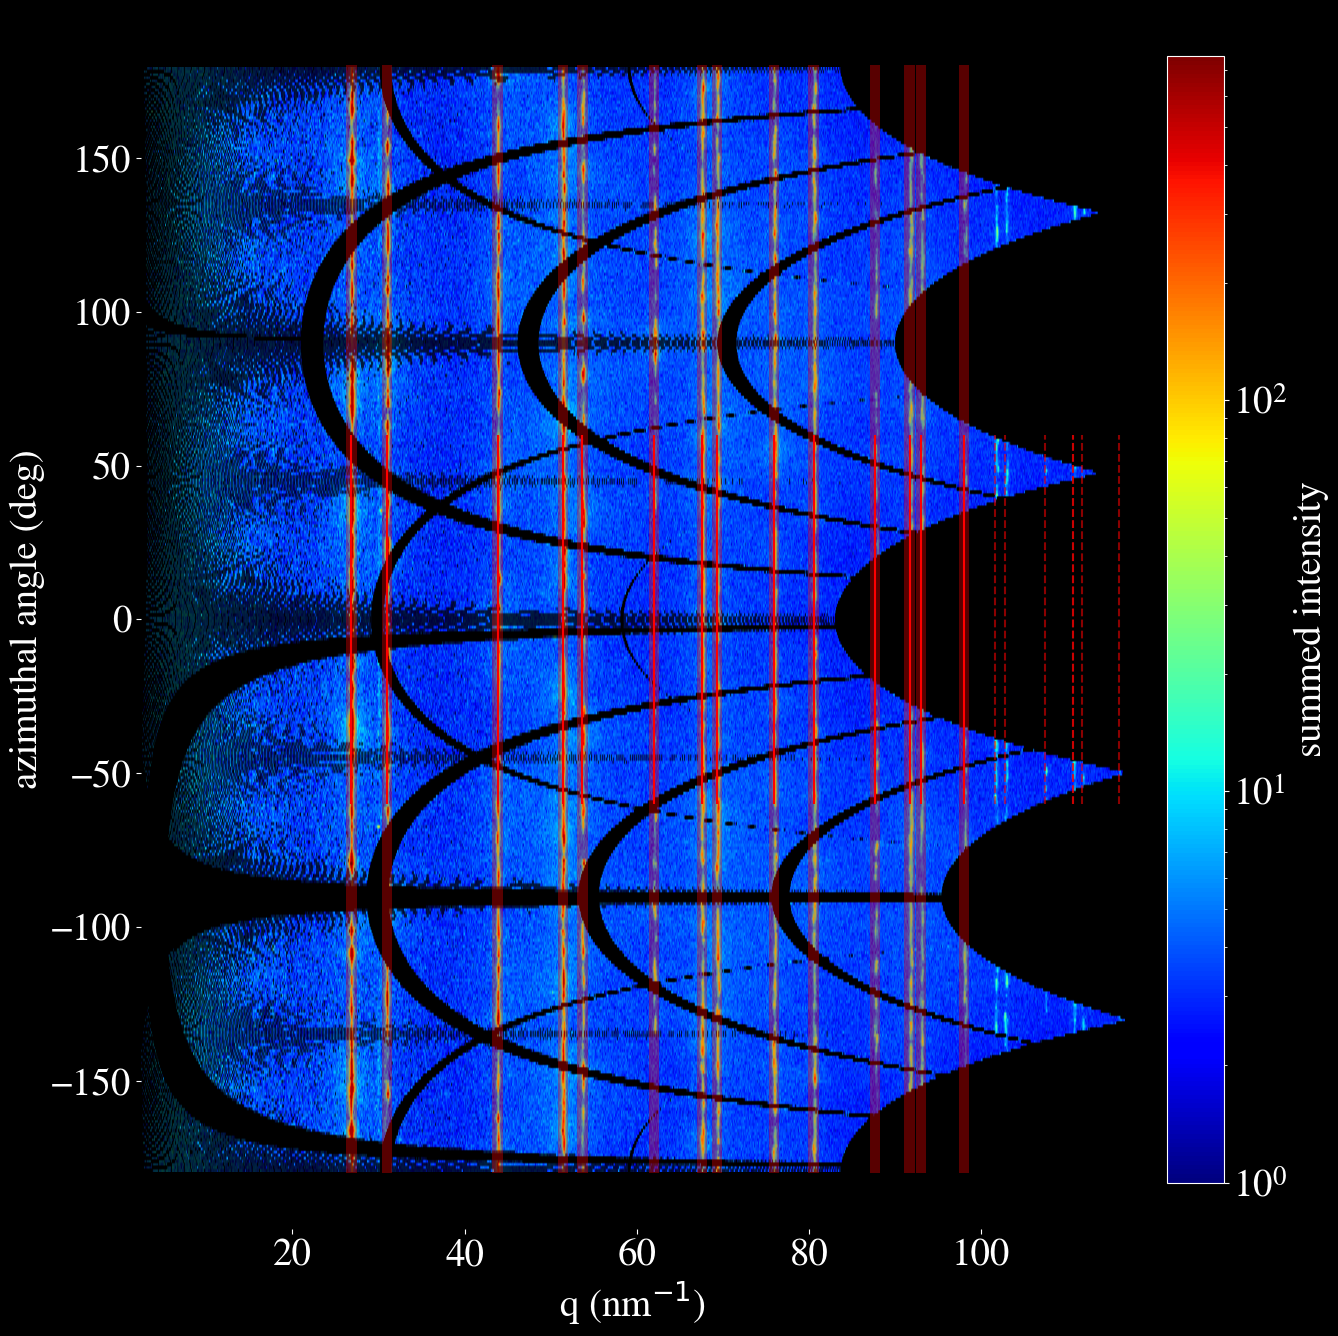

In [5]:
# --- q-width used for the integration bin around each selected peak ---
Q_WIDTH_NM = 1.2  # full width, in nm^-1 (same units as the q axis below)

# --- load geometry and integrate as before ---
ai = pyFAI.load(PONI_PATH)

npt_rad = 2000
npt_azim = 360

target_trans_frac = [0.25, 0.5, 0.75]
target_omega_deg = [0, 90, 180, 270, 360]

I_sum, q, chi = None, None, None

with DanMaxDataset() as ds:
    mask = ds.mask()
    n_trans = ds.n_translations
    i_trans_list = [int(round(f * (n_trans - 1))) for f in target_trans_frac]

    for i_trans in i_trans_list:
        omega = ds.omega(i_trans)
        for target in target_omega_deg:
            i_omega = int(np.argmin(np.abs(omega - target)))
            frame = ds.frame(i_trans, i_omega)

            res = ai.integrate2d(
                frame,
                npt_rad=npt_rad,
                npt_azim=npt_azim,
                unit="q_nm^-1",
                mask=mask,
                method=("no", "csr", "opencl"),
            )

            if I_sum is None:
                I_sum = np.zeros_like(res.intensity)
                q, chi = res.radial, res.azimuthal

            I_sum += res.intensity

I_sum = np.nan_to_num(I_sum)

# --- predict theoretical peak positions from the .par file (extinctions applied) ---
def read_par_file(path):
    params = {}
    with open(path) as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 2:
                params[parts[0]] = parts[1]
    return params

par = read_par_file(PARAMETERS_AL1050)

q_min_A = q.min() / 10  # detector q-range: nm^-1 -> Å^-1
q_max_A = q.max() / 10

mat = Material.from_lattice_parameters(
    a=float(par["cell__a"]),
    b=float(par["cell__b"]),
    c=float(par["cell__c"]),
    alpha=float(par["cell_alpha"]),
    beta=float(par["cell_beta"]),
    gamma=float(par["cell_gamma"]),
    space_group_number=int(par["cell_lattice_[P,A,B,C,I,F,R]"]),
    wavelength_A=float(par["wavelength"]),
    q_min=q_min_A,
    q_max=q_max_A,
)

q_peaks_A = 2 * np.pi / mat.reflections["d_spacing"]
q_peaks_nm = np.unique(q_peaks_A * 10)  # back to nm^-1, ascending, deduped

selected_peaks = q_peaks_nm[:-7]
excluded_peaks = q_peaks_nm[-7:]

print(f"{len(selected_peaks)} peaks selected for integration, "
      f"{len(excluded_peaks)} highest-q peaks excluded")

# --- plot, same theme as before, with selected/excluded peaks and q-width ---
vmin = max(I_sum[I_sum > 0].min(), 1)
vmax = np.percentile(I_sum, 99.9)

fig, ax = plt.subplots(1, 1, figsize=(14, 14))
im = ax.imshow(
    I_sum,
    extent=[q.min(), q.max(), chi.min(), chi.max()],
    origin="lower",
    aspect="auto",
    vmin=vmin, vmax=vmax, norm="log",
    cmap="jet",
)

for peak in selected_peaks:
    ax.vlines(peak, ymin=-60, ymax=60, color="red", linewidth=1.5)


for peak in selected_peaks:
    ax.add_patch(Rectangle(
        (peak - Q_WIDTH_NM / 2, -180), Q_WIDTH_NM, 360,
        facecolor="red", alpha=0.35, edgecolor=None,
    ))

for peak in excluded_peaks:
    ax.vlines(peak, ymin=-60, ymax=60, color="red", linewidth=1.5,
               linestyle="--", alpha=0.55)

ax.set_xlabel(r"q (nm$^{-1}$)")
ax.set_ylabel("azimuthal angle (deg)")
fig.colorbar(im, ax=ax, fraction=0.052, pad=0.04, label="summed intensity")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

Q_WIDTH_NM = 1.2
npt_rad_fine = 2000
N_eta = 360

target_trans_frac = [0.25, 0.5, 0.75]
target_omega_deg = [0, 90, 180, 270, 360]

radial_ranges = [(p - Q_WIDTH_NM / 2, p + Q_WIDTH_NM / 2) for p in selected_peaks]
N_rings = len(radial_ranges)
q_range_min = min(lo for lo, hi in radial_ranges)
q_range_max = max(hi for lo, hi in radial_ranges)
n_bins_per_ring = 10  # only affects how precisely ring edges are resolved, not the final merged value
npt_rad_fast = int((q_range_max - q_range_min) / Q_WIDTH_NM * n_bins_per_ring)

I_sum, q, chi = None, None, None
I_fast_sum = None

with DanMaxDataset() as ds:
    mask = ds.mask()
    n_trans = ds.n_translations
    i_trans_list = [int(round(f * (n_trans - 1))) for f in target_trans_frac]

    for i_trans in i_trans_list:
        omega = ds.omega(i_trans)
        for target in target_omega_deg:
            i_omega = int(np.argmin(np.abs(omega - target)))
            frame = ds.frame(i_trans, i_omega)

            res = ai.integrate2d(
                frame, npt_rad=npt_rad_fine, npt_azim=N_eta,
                unit="q_nm^-1", mask=mask, method=("no", "csr", "opencl"),
            )
            if I_sum is None:
                I_sum = np.zeros_like(res.intensity)
                q, chi = res.radial, res.azimuthal
            I_sum += res.intensity

            res_fast = ai.integrate2d(
                frame, npt_rad=npt_rad_fast, npt_azim=N_eta,
                radial_range=(q_range_min, q_range_max), unit="q_nm^-1",
                mask=mask, method=("no", "csr", "opencl"),
            )
            if I_fast_sum is None:
                I_fast_sum = np.zeros_like(res_fast.intensity)
                fast_q = res_fast.radial
            I_fast_sum += res_fast.intensity

I_sum = np.nan_to_num(I_sum)
I_fast_sum = np.nan_to_num(I_fast_sum)

# the actual per-ring, per-eta merged values -- exactly what the production pipeline outputs
ring_masks_fast = [(fast_q >= lo) & (fast_q < hi) for lo, hi in radial_ranges]
I_rings_merged = np.stack([I_fast_sum[:, sel].sum(axis=1) for sel in ring_masks_fast], axis=1)  # (N_eta, N_rings)

# numeric check against the fine reference, unchanged

# build the merged-value image: each ring's q-window filled with one flat color
merged_image = np.full_like(fast_q, np.nan)[None, :].repeat(N_eta, axis=0)
for i_ring, sel in enumerate(ring_masks_fast):
    merged_image[:, sel] = I_rings_merged[:, i_ring:i_ring + 1]  # broadcast over q within the window

vmin_ref = max(I_sum[I_sum > 0].min(), 1)
vmax_ref = np.percentile(I_sum, 99.99)
vmin_merged = max(I_rings_merged[I_rings_merged > 0].min(), 1)
vmax_merged = np.percentile(I_rings_merged, 99.9)

fig, axes = plt.subplots(2, 1, figsize=(14, 16), height_ratios=[1, 1])

# --- panel 1: fine reference ---
ax = axes[0]
im = ax.imshow(
    I_sum, extent=[q.min(), q.max(), chi.min(), chi.max()],
    origin="lower", aspect="auto", vmin=vmin_ref, vmax=vmax_ref, norm="log", cmap="jet",
)
for peak in selected_peaks:
    ax.vlines(peak, ymin=-60, ymax=60, color="red", linewidth=1.5)
    ax.add_patch(Rectangle(
        (peak - Q_WIDTH_NM / 2, chi.min()), Q_WIDTH_NM, chi.max() - chi.min(),
        facecolor="red", alpha=0.25, edgecolor=None,
    ))
for peak in excluded_peaks:
    ax.vlines(peak, ymin=-60, ymax=60, color="red", linewidth=1.5,
               linestyle="--", alpha=0.55)
ax.set_xlabel(r"q (nm$^{-1}$)")
ax.set_ylabel("azimuthal angle (deg)")
ax.set_title("fine reference integration")
fig.colorbar(im, ax=ax, fraction=0.052, pad=0.04, label="summed intensity (per bin)")
for spine in ax.spines.values():
    spine.set_visible(False)

# --- panel 2: merged production values, own color scale, same x-axis ---
ax_mid = axes[1]
im_mid = ax_mid.imshow(
    merged_image, extent=[fast_q.min(), fast_q.max(), chi.min(), chi.max()],
    origin="lower", aspect="auto", vmin=vmin_ref, vmax=vmax_ref, norm="log", cmap="jet",
)
ax_mid.set_xlim(q.min(), q.max())
ax_mid.set_xlabel(r"q (nm$^{-1}$)")
ax_mid.set_ylabel("azimuthal angle (deg)")
ax_mid.set_title("merged per-ring intensity (actual production output; note different color scale)")
fig.colorbar(im_mid, ax=ax_mid, fraction=0.052, pad=0.04, label="merged intensity (per ring)")
for spine in ax_mid.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [20]:
import time
import numpy as np
import pyFAI

ai = pyFAI.load(PONI_PATH)

N_eta = 720
batch_size = 300  # doesn't need to divide n_omega evenly -- last batch is just smaller

# selected_peaks, Q_WIDTH_NM from the previous notebook cell
radial_ranges = [(p - Q_WIDTH_NM / 2, p + Q_WIDTH_NM / 2) for p in selected_peaks]
N_rings = len(radial_ranges)

q_range_min = min(lo for lo, hi in radial_ranges)
q_range_max = max(hi for lo, hi in radial_ranges)

# fine enough to resolve each ring's width into several bins -- tune if needed
n_bins_per_ring = 10
npt_rad = int((q_range_max - q_range_min) / Q_WIDTH_NM * n_bins_per_ring)

with DanMaxDataset() as ds:
    mask = ds.mask()
    i_trans = ds.n_translations // 2
    n_omega = ds.n_omega(i_trans)

    def integrate_one(frame):
        return ai.integrate2d(
            frame,
            npt_rad=npt_rad,
            npt_azim=N_eta,
            radial_range=(q_range_min, q_range_max),
            unit="q_nm^-1",
            mask=mask,
            method=("no", "csr", "opencl"),
        )

    # --- warm-up: builds/caches the CSR engine (paid once total) ---
    first_frame = ds.frame(i_trans, 0)
    t0 = time.perf_counter()
    res0 = integrate_one(first_frame)
    warmup_s = time.perf_counter() - t0
    print(f"warm-up (engine build): {warmup_s:.2f} s")

    # precompute, once, which output q-bins belong to which ring
    q_bins = res0.radial
    ring_masks = [(q_bins >= lo) & (q_bins < hi) for lo, hi in radial_ranges]

    def integrate_frame(frame):
        res = integrate_one(frame)  # ONE call per frame now, not one per ring
        I = res.intensity  # (N_eta, npt_rad)
        out = np.empty((N_eta, N_rings), dtype=np.float32)
        for i_ring, sel in enumerate(ring_masks):
            out[:, i_ring] = I[:, sel].sum(axis=1)
        return out

    # --- steady-state ---
    I_out = np.empty((n_omega, N_eta, N_rings), dtype=np.float32)

    t0 = time.perf_counter()
    count = 0
    for start in range(0, n_omega, batch_size):
        count += 1
        stop = min(start + batch_size, n_omega)
        frames = ds.frames(i_trans, slice(start, stop))
        for i, frame in enumerate(frames):
            I_out[start + i] = integrate_frame(frame)
    steady_s = time.perf_counter() - t0

    per_frame_ms = 1000 * steady_s / n_omega
    print(f"steady-state: {steady_s:.1f} s for {n_omega} frames "
          f"({per_frame_ms:.2f} ms/frame)")

    total_frames = sum(ds.n_omega(i) for i in range(ds.n_translations))
    est_total_s = per_frame_ms / 1000 * total_frames
    print(f"estimated full-dataset time ({total_frames} frames): "
          f"{est_total_s / 60:.1f} min")

warm-up (engine build): 2.63 s
steady-state: 47.5 s for 3003 frames (15.83 ms/frame)
estimated full-dataset time (543543 frames): 143.4 min


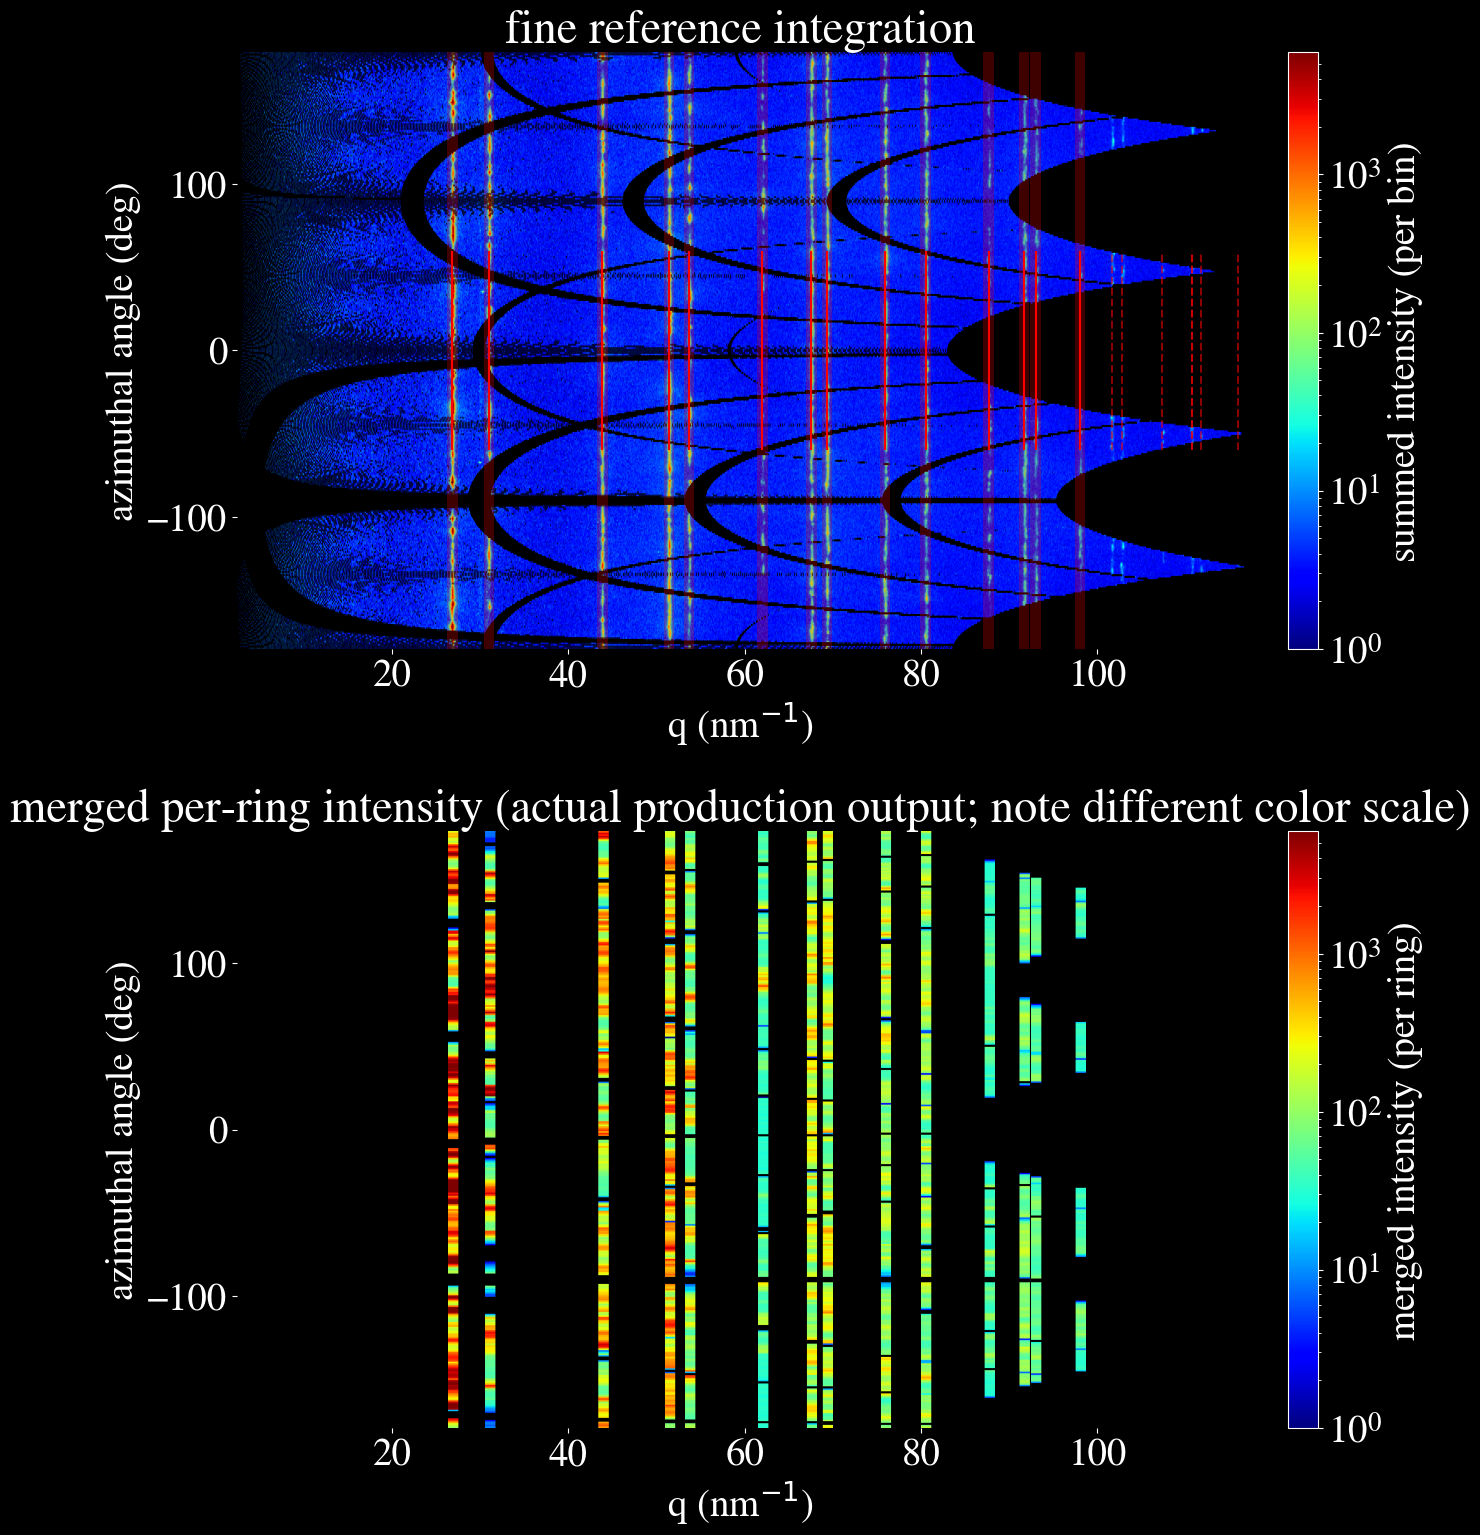